<a href="https://colab.research.google.com/github/siskamr17-code/Data-Mining_UTS/blob/main/UTS%20DATMIN_030.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive, files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import joblib

drive.mount('/content/drive')
print("Libraries loaded")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries loaded


In [ ]:
print("Upload data_training.csv")
uploaded_train = files.upload()
train_file = list(uploaded_train.keys())[0]
df_train = pd.read_csv(train_file)
print(f"Train shape: {df_train.shape}")

Upload data_training.csv


Saving data_training.csv to data_training (1).csv
Train shape: (857, 13)


In [ ]:
print("Upload data_testing.csv")
uploaded_test = files.upload()
test_file = list(uploaded_test.keys())[0]
df_test = pd.read_csv(test_file)
print(f"Test shape: {df_test.shape}")

Upload data_testing.csv


Saving data_testing.csv to data_testing (1).csv
Test shape: (286, 12)


In [ ]:
print(df_train.info())
print("\nTarget distribution:")
print(df_train['quality'].value_counts().sort_index())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
None

Target distribution:
quality
3      6
4     26
5    362
6    341
7    10

In [ ]:
features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
            'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
            'pH', 'sulphates', 'alcohol']

X = df_train[features]
y = df_train['quality']
X_test = df_test[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, 'scaler.pkl')
print(f"X_scaled shape: {X_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_scaled shape: (857, 11)
X_test_scaled shape: (286, 11)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape[0]}, Validation: {X_val.shape[0]}")

Train: 685, Validation: 172


In [ ]:
models = {
    'RF': RandomForestClassifier(n_estimators=100, random_state=42),
    'GB': GradientBoostingClassifier(random_state=42),
    'DT': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'LR': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    cv = cross_val_score(model, X_scaled, y, cv=5).mean()
    results.append({'Model': name, 'Accuracy': acc, 'CV_Mean': cv})
    print(f"{name}: Acc={acc:.4f}, CV={cv:.4f}")

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print("\nBest Model:", results_df.iloc[0]['Model'])

RF: Acc=0.6279, CV=0.6382
GB: Acc=0.6221, CV=0.5997
DT: Acc=0.6047, CV=0.5577
KNN: Acc=0.4942, CV=0.5414
LR: Acc=0.6105, CV=0.5904
SVM: Acc=0.5988, CV=0.6056

Best Model: RF


In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV score: {grid.best_score_:.4f}")

best_rf = grid.best_estimator_

Best params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.6161


                 Feature  Importance
10               alcohol    0.155595
9              sulphates    0.125860
1       volatile acidity    0.114732
6   total sulfur dioxide    0.094971
7                density    0.082668
4              chlorides    0.079755
0          fixed acidity    0.074713
2            citric acid    0.073018
8                     pH    0.070228
5    free sulfur dioxide    0.064536
3         residual sugar    0.063924


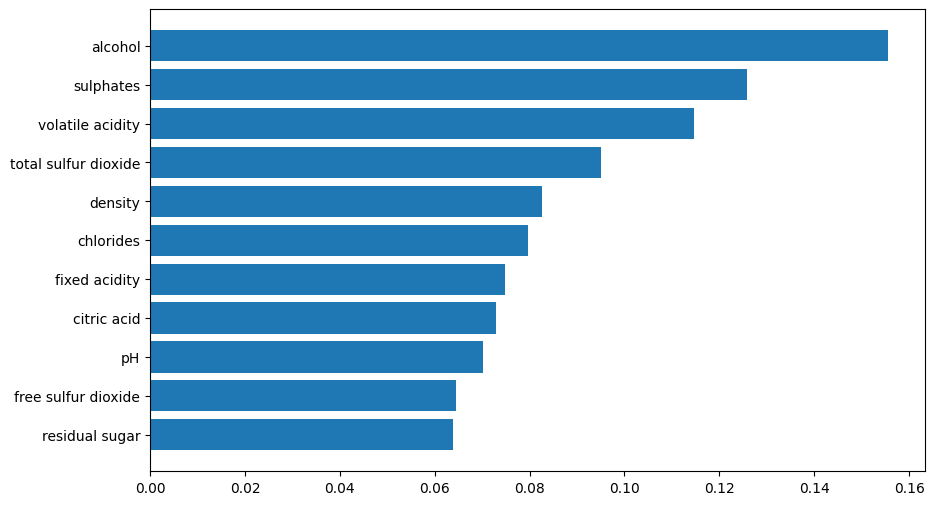

In [ ]:
final_model = RandomForestClassifier(**grid.best_params_, random_state=42)
final_model.fit(X_scaled, y)

joblib.dump(final_model, 'model.pkl')

# Feature importance
imp = pd.DataFrame({'Feature': features, 'Importance': final_model.feature_importances_}).sort_values('Importance', ascending=False)
print(imp)

plt.figure(figsize=(10,6))
plt.barh(imp['Feature'], imp['Importance'])
plt.gca().invert_yaxis()
plt.show()

In [ ]:
predictions = final_model.predict(X_test_scaled)

print(f"Predictions distribution:")
unique, counts = np.unique(predictions, return_counts=True)
for q, c in zip(unique, counts):
    print(f"  Quality {q}: {c} ({c/len(predictions)*100:.1f}%)")

Predictions distribution:
  Quality 5: 128 (44.8%)
  Quality 6: 130 (45.5%)
  Quality 7: 28 (9.8%)


In [ ]:
NIM = "030"

submission = pd.DataFrame({
    'Id': df_test['Id'],
    'quality': predictions
})

filename = f"hasilprediksi_{NIM}.csv"
submission.to_csv(filename, index=False)
print(f"Saved: {filename}")

print(f"Shape: {submission.shape}")
print(f"Columns: {list(submission.columns)}")
print(submission.head())

Saved: hasilprediksi_030.csv
Shape: (286, 2)
Columns: ['Id', 'quality']
     Id  quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        6
